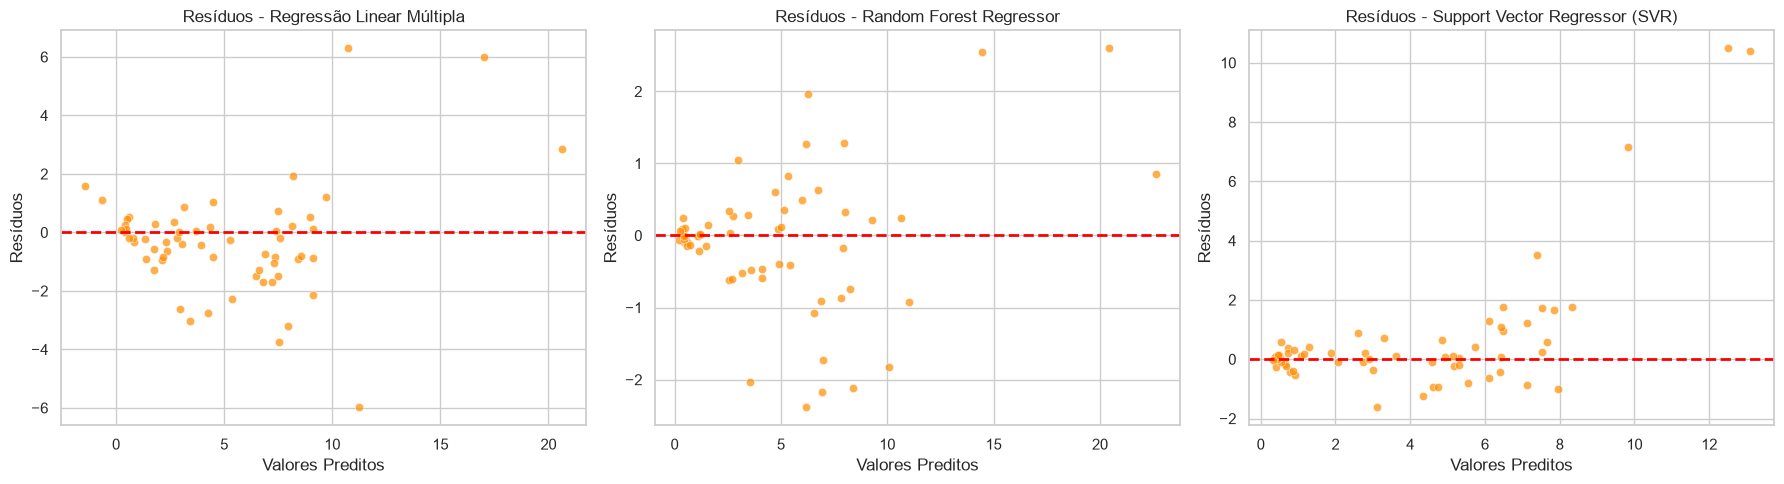

In [8]:
# ==========================================
# 7. ANÁLISE DE RESÍDUOS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals = [
    ("Regressão Linear Múltipla", y_test - y_pred_lr, y_pred_lr),
    ("Random Forest Regressor", y_test - y_pred_rf, y_pred_rf),
    ("Support Vector Regressor (SVR)", y_test - y_pred_svr, y_pred_svr)
]

for i, (name, res, preds) in enumerate(residuals):
    sns.scatterplot(x=preds, y=res, ax=axes[i], alpha=0.7, color='darkorange')
    axes[i].axhline(0, color='red', linestyle='--', lw=2)
    axes[i].set_title(f"Resíduos - {name}")
    axes[i].set_xlabel("Valores Preditos")
    axes[i].set_ylabel("Resíduos")

plt.tight_layout()
plt.show()


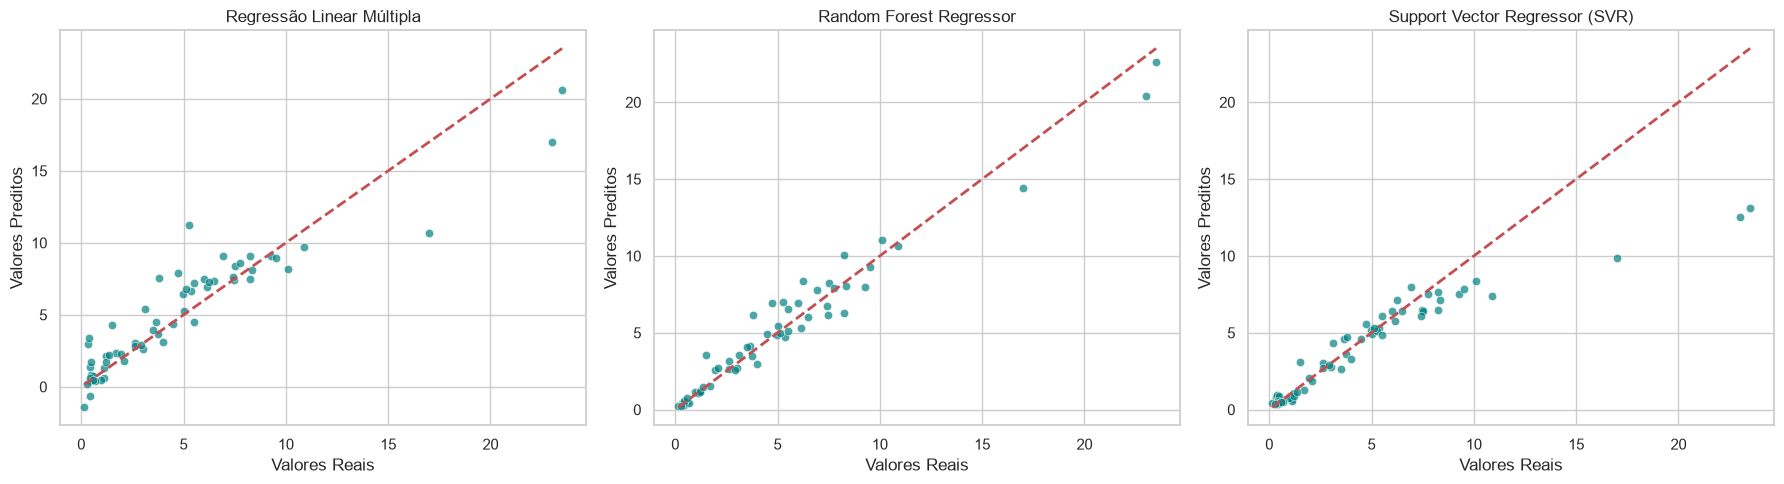

In [7]:
# ==========================================
# 6. VISUALIZAÇÕES DE PERFORMANCE (Reais vs. Preditos)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ("Regressão Linear Múltipla", y_pred_lr),
    ("Random Forest Regressor", y_pred_rf),
    ("Support Vector Regressor (SVR)", y_pred_svr)
]

for i, (name, preds) in enumerate(models_preds):
    sns.scatterplot(x=y_test, y=preds, ax=axes[i], alpha=0.7, color='teal')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
    axes[i].set_title(f"{name}")
    axes[i].set_xlabel("Valores Reais")
    axes[i].set_ylabel("Valores Preditos")

plt.tight_layout()
plt.show()


In [5]:
# ==========================================
# 5. AVALIAÇÃO DE MÉTRICAS E TABELA COMPARATIVA
# ==========================================

def evaluate_model(true, pred, model_name):
    r2 = r2_score(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    # MAPE seguro contra divisão por zero
    mape = np.mean(np.abs((true - pred) / np.maximum(np.abs(true), 1e-8))) * 100
    return {"Modelo": model_name, "R2": r2, "MAE": mae, "MAPE (%)": mape, "RMSE": rmse}

# Previsões utilizando o dicionário 'models' treinado no Passo 4
y_pred_lr = models["Linear Regression"].predict(X_test_scaled)
y_pred_rf = models["Random Forest"].predict(X_test)
y_pred_svr = models["SVR (Support Vector Regressor)"].predict(X_test_scaled)

# Compilando os resultados na Tabela Comparativa exigida
results = [
    evaluate_model(y_test, y_pred_lr, "Regressão Linear Múltipla"),
    evaluate_model(y_test, y_pred_rf, "Random Forest Regressor"),
    evaluate_model(y_test, y_pred_svr, "Support Vector Regressor (SVR)")
]

df_results = pd.DataFrame(results)
print("\n=== TABELA COMPARATIVA DE MÉTRICAS ===")
display(df_results.round(4))


=== TABELA COMPARATIVA DE MÉTRICAS ===


,Modelo,R2,MAE,MAPE (%),RMSE
0,Regressão Linear Múltipla,0.8490,1.2162,80.3597,1.8652
1,Random Forest Regressor,0.9599,0.6408,17.3354,0.9610
2,Support Vector Regressor (SVR),0.7777,1.0108,25.7365,2.2627


In [6]:
# ==========================================
# 4. PADRONIZAÇÃO E TREINAMENTO DOS MODELOS
# ==========================================

# Padronizando as features (média 0 e desvio padrão 1)
# O StandardScaler é fitado apenas no treino para evitar Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dicionário com os modelos que serão testados
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR (Support Vector Regressor)": SVR()
}

# Treinando cada modelo
for name, model in models.items():
    if name in ["Linear Regression", "SVR (Support Vector Regressor)"]:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


In [3]:
# ==========================================
# 3. SEPARAÇÃO DOS DADOS E TREINO/TESTE
# ==========================================

# Separando a variável alvo (y) das features preditoras (X)
X = df_model.drop(columns=['Selling_Price'])
y = df_model['Selling_Price']

# Dividindo os dados em 80% para treino e 20% para teste
# random_state fixo garante a reprodutibilidade dos resultados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensões do conjunto de treino (X_train): {X_train.shape}")
print(f"Dimensões do conjunto de teste (X_test): {X_test.shape}")

Dimensões do conjunto de treino (X_train): (240, 8)
Dimensões do conjunto de teste (X_test): (61, 8)


Arquivo carregado com sucesso! Shape original: (301, 9)

--- Shape após One-Hot Encoding --- (301, 9)

--- Estatísticas Descritivas ---


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,0.043189,5.372093
std,5.082812,8.644115,38886.883882,0.247915,2.891554
min,0.100000,0.320000,500.000000,0.000000,1.000000
25%,0.900000,1.200000,15000.000000,0.000000,3.000000
50%,3.600000,6.400000,32000.000000,0.000000,5.000000
75%,6.000000,9.900000,48767.000000,0.000000,7.000000
max,35.000000,92.600000,500000.000000,3.000000,16.000000


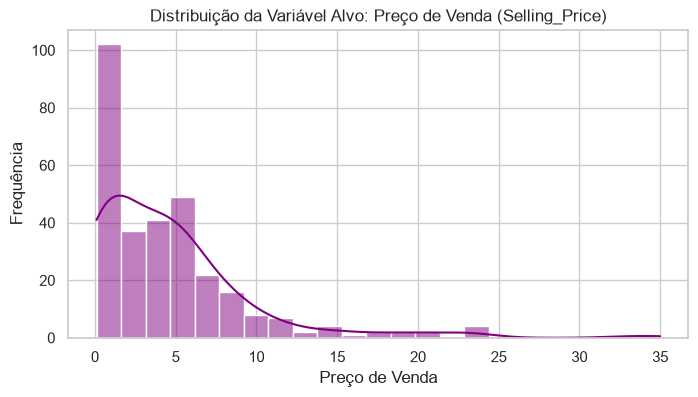

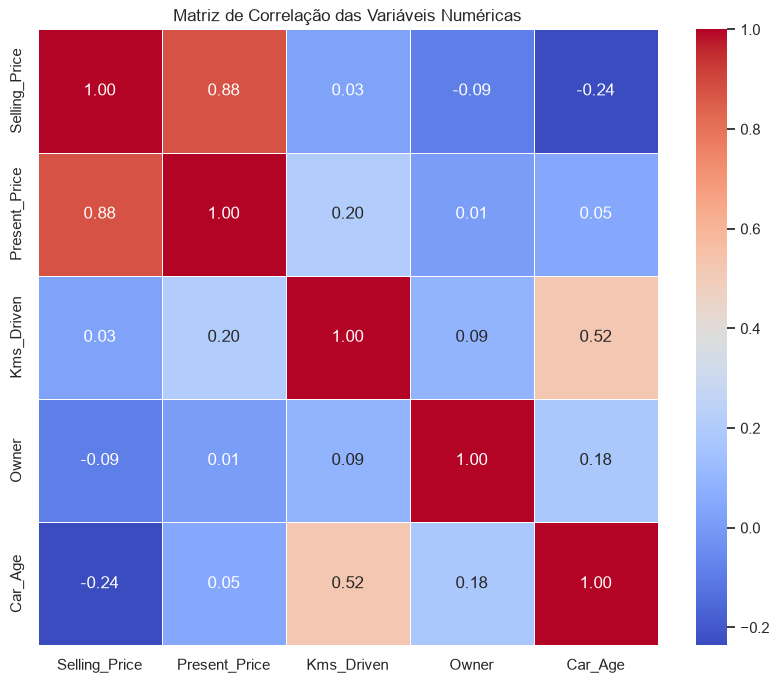

In [2]:
# ==========================================
# 2. CARREGAMENTO E ANÁLISE EXPLORATÓRIA (EDA)
# ==========================================

df = pd.read_csv("Vehicle-DS.csv")
print("Arquivo carregado com sucesso! Shape original:", df.shape)

# Engenharia de Feature: Criando a idade do veículo com base no ano máximo do dataset
current_year = df['Year'].max() + 1
df['Car_Age'] = current_year - df['Year']

# Removendo 'Car_Name' por alta cardinalidade e 'Year' (pois já criamos 'Car_Age')
df_model = df.drop(columns=['Car_Name', 'Year'])

# Conversão de Variáveis Categóricas (One-Hot Encoding) para o modelo aceitar
# O parâmetro drop_first=True evita multicolinearidade
df_model = pd.get_dummies(df_model, drop_first=True)

print("\n--- Shape após One-Hot Encoding ---", df_model.shape)

print("\n--- Estatísticas Descritivas ---")
display(df_model.describe())

# Visualizando a distribuição da Variável Alvo (Selling_Price)
plt.figure(figsize=(8, 4))
sns.histplot(df_model['Selling_Price'], kde=True, color='purple')
plt.title('Distribuição da Variável Alvo: Preço de Venda (Selling_Price)')
plt.xlabel('Preço de Venda')
plt.ylabel('Frequência')
plt.show()

# Heatmap de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df_model.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

In [1]:
# ==========================================
# ==========================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!
